# Mental health in the Tech Industry (2014-2019)

This project has a purpose to explore the *Mental Health in the Tech Industry* Kaggle dataset. The tech industry has seen rising awareness around mental health challenges, yet data-driven insights are essential for identifying the populations most affected and understanding how mental health impacts workplace productivity.

More specifically, this notebook's objective is to answer the following questions: 
1. Who participated in the survey? 
2. Which mental health conditions are most prevalent for this population? 
3. How does treatment for mental health conditions affect productivity at work?

Notebook structure: 
- Initial table examination
- Sociodemographic Overview
- Mental Health overview
- Diagnosed condition prevalence
- Link with mental health conditions and workplace productivity. 

Importing necessary libraries: 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import textwrap
from helpers import question_missing_stats, wrap_labels, ME
%matplotlib inline

Setting a consistent color palette and parameters for plots: 

In [2]:
sns.set_theme(style="white", context="talk")
PALETTE = sns.color_palette("tab10", n_colors=5)
ACCENT_COLOR = PALETTE[0]
sns.set_palette(PALETTE)
plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["legend.title_fontsize"] = 12
plt.rcParams["legend.fontsize"] = 12


# Database connection and initial viewing

In [3]:
database = "mental_health.sqlite"

In [4]:
connection = sql.connect(database)

## Survey table: 

Starting by looking at the survey table: 

In [5]:
survey_query = """
SELECT * 
FROM Survey
"""
survey = pd.read_sql(survey_query, connection)
survey

,SurveyID,Description
0,2014,mental health survey for 2014
1,2016,mental health survey for 2016
2,2017,mental health survey for 2017
3,2018,mental health survey for 2018
4,2019,mental health survey for 2019


In [6]:
survey.dtypes

SurveyID        int64
Description    object
dtype: object

This table shows years for which mental health surveys are present (2014, 2016-2019). SurveyID is of type int, and the description is of type object.

## Question table

Looking at the question table: 

In [7]:
question_query = """
SELECT * 
FROM Question
"""
question = pd.read_sql(question_query, connection)
pd.set_option("max_colwidth", None)
question

,questiontext,questionid
0,What is your age?,1
1,What is your gender?,2
2,What country do you live in?,3
3,"If you live in the United States, which state or territory do you live in?",4
4,Are you self-employed?,5
...,...,...
100,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,114
101,"If yes, what condition(s) have you been diagnosed with?",115
102,"If maybe, what condition(s) do you believe you have?",116
103,Which of the following best describes your work position?,117


This table contains all the survey questions, with questionid. 

In [8]:
len(question)

105

In [9]:
question.dtypes

questiontext    object
questionid       int64
dtype: object

There are 105 questions in total, where questionid is an integer and the question text is an object. 

## Answer table

Looking at the answer table: 

In [10]:
answer_query = """ 
SELECT * 
FROM Answer
"""
answer = pd.read_sql(answer_query, connection)
answer.head()

,AnswerText,SurveyID,UserID,QuestionID
0,37,2014,1,1
1,44,2014,2,1
2,32,2014,3,1
3,31,2014,4,1
4,31,2014,5,1


In [11]:
len(answer)

236898

In [12]:
answer.dtypes

AnswerText    object
SurveyID       int64
UserID         int64
QuestionID     int64
dtype: object

This table provides all answers to survey questions. It includes user ID, question ID, and survey ID as integers. In total, there are almost 237 thousand answers. 

# Sociodemographic Overview

Looking at total survey participants each year: 

In [13]:
total_participants = """
SELECT COUNT(DISTINCT(UserID)) AS total_participants
FROM Answer
"""
total_participants = pd.read_sql(total_participants, connection)
total_participants

,total_participants
0,4218


There were 4218 total survey participants. By year: 

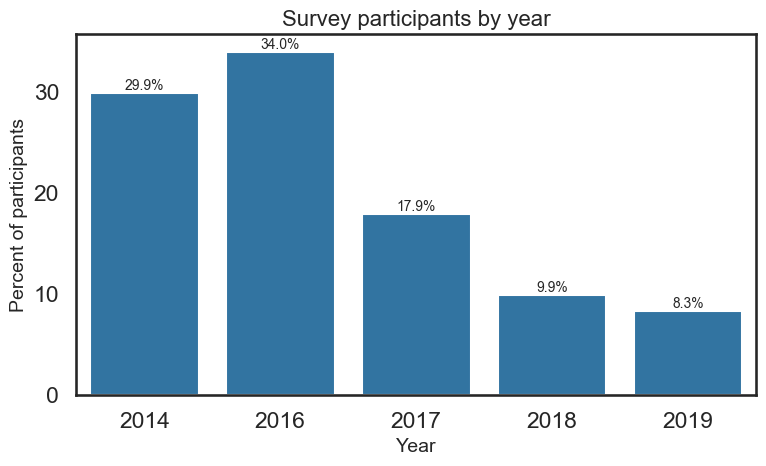

In [14]:
total_participants = 4218

survey_sample_year = """
SELECT SurveyID AS Year, COUNT(DISTINCT UserID) AS num_survey_answers
FROM Answer
GROUP BY SurveyID
"""
num_survey_year = pd.read_sql(survey_sample_year, connection)
num_survey_year["percent"] = 100 * num_survey_year["num_survey_answers"] / total_participants

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=num_survey_year, x="Year", y="percent")

ax.set(
    title="Survey participants by year",
    ylabel="Percent of participants",
)
ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=10)
plt.tight_layout()


The number of survey participants increases slightly between 2014-2016 and decreases after that. 

## Country

Looking at country where participants live and work: 

In [15]:
q = """ 
WITH home AS (WITH t1 AS (SELECT CASE WHEN AnswerText LIKE 'United States' THEN 'United States of America' 
        WHEN AnswerText LIKE 'United States of America' THEN 'United States of America' 
        WHEN AnswerText = -1 THEN 'Other'
        ELSE AnswerText END AS home_country
        FROM Answer
        WHERE QuestionID = 3)

    SELECT home_country, COUNT(home_country) home_country_frequency
    FROM t1
    GROUP BY 1
    ORDER BY 2 DESC), 

work AS (SELECT AnswerText work_country, COUNT(AnswerText) work_country_frequency
    FROM Answer
    WHERE QuestionID = 50
    GROUP BY AnswerText
    ORDER BY 2 DESC)

SELECT home.home_country, work.work_country, home.home_country_frequency, work.work_country_frequency
FROM home
FULL JOIN work
ON home_country = work_country
LIMIT 10;
"""
country = pd.read_sql(q, connection)
country.head()

,home_country,work_country,home_country_frequency,work_country_frequency
0,United States of America,United States of America,2604,1872
1,United Kingdom,United Kingdom,482,300
2,Canada,Canada,199,122
3,Germany,Germany,136,90
4,Netherlands,Netherlands,98,70


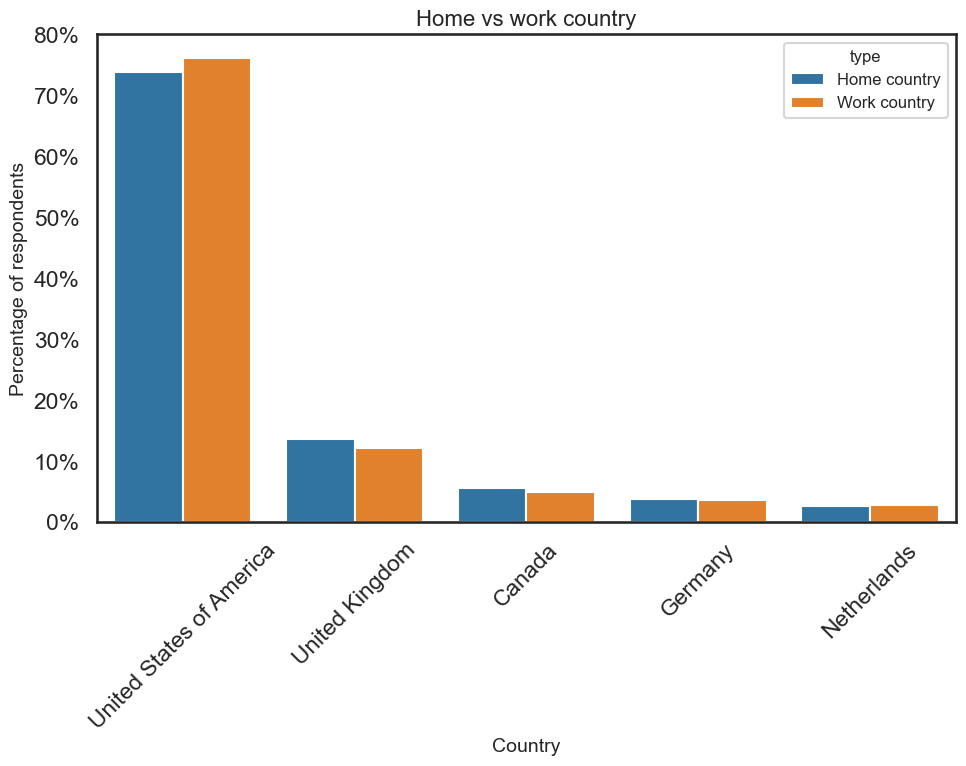

In [16]:
country_plot = country.head().copy()
country_plot["country"] = country_plot["home_country"].fillna(country_plot["work_country"])

country_long = country_plot.melt(
    id_vars="country",
    value_vars=["home_country_frequency", "work_country_frequency"],
    var_name="type",
    value_name="frequency",
).dropna(subset=["frequency"])

country_long["type"] = country_long["type"].map({
    "home_country_frequency": "Home country",
    "work_country_frequency": "Work country",
})
country_long["share"] = (
    country_long["frequency"] /
    country_long.groupby("type")["frequency"].transform("sum")
)

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=country_long,
    x="country",
    y="share",
    hue="type",
)

ax.set(
    title="Home vs work country",
    xlabel="Country",
    ylabel="Percentage of respondents",
)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()


Most survey respondents are from the USA, UK, or Canada. In general for the top 10 countries, it seems that the home_country_frequency is higher than the work_country_frequency. For the rest of this analysis, the work_country_frequency will be used, as the topic involves the workplace. The total survey respondents in these countries are: 

In [17]:
q = """
SELECT COUNT(DISTINCT UserID) AS n_participants_work_US_UK_CA
FROM Answer
WHERE QuestionID = 50
  AND AnswerText IN ('United States', 'United States of America', 'United Kingdom', 'Canada');
"""
total_participants_USA_UK_Canada = pd.read_sql(q, connection)
total_participants_USA_UK_Canada

,n_participants_work_US_UK_CA
0,2294


In [18]:
total_participants_USA_UK_Canada = 2294
total_participants_USA = 1872

## Age
Now, examining the age of survey participants: 

Are there any missing age values? 

In [19]:
question_missing_stats(1, total=total_participants)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,1,4218,5,0.11854,0.11854


Barely any missing age values are present. Looking at participant age: 

In [20]:
q = """ 
SELECT AnswerText Age, COUNT(AnswerText) Age_frequency
FROM Answer
WHERE QuestionID = 1
GROUP BY 1
ORDER BY 1
"""
age = pd.read_sql(q, connection)
age = age.astype({"Age": "int64"})
age.describe()


,Age,Age_frequency
count,65.000000,65.000000
mean,48.015385,64.892308
std,54.539977,79.612759
min,-29.000000,1.000000
25%,25.000000,3.000000
50%,41.000000,20.000000
75%,57.000000,122.000000
max,329.000000,250.000000


Some ages are invalid: 
- Accidental negative age
- Maximum of 329

Therefore, examing ages between 15-70 years only: 

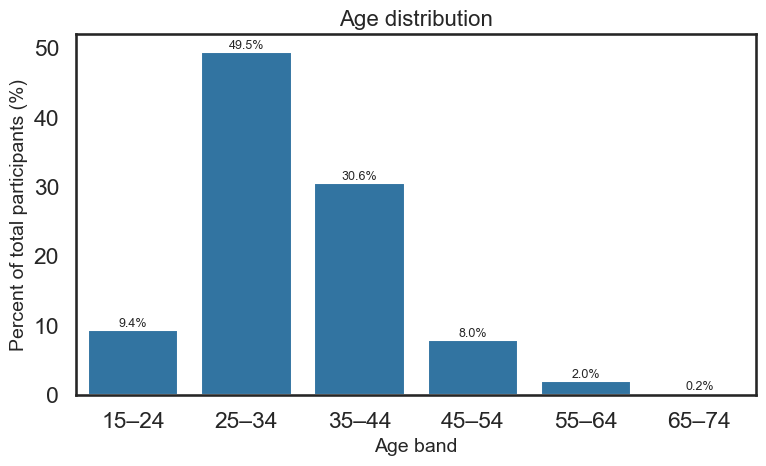

In [21]:
age_band = age.copy()
age_band["age_band"] = pd.cut(
    age_band["Age"],
    bins=[15, 24, 34, 44, 54, 64, 74],
    labels=["15–24", "25–34", "35–44", "45–54", "55–64", "65–74"],
    right=True,
)
band_summary = (
    age_band.groupby("age_band", observed=False)["Age_frequency"]
            .sum()
            .reset_index()
            .rename(columns={"Age_frequency": "n"})
)
band_summary["percent"] = 100 * band_summary["n"] / total_participants
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=band_summary, x="age_band", y="percent", color=ACCENT_COLOR)
ax.set(
    title="Age distribution",
    xlabel="Age band",
    ylabel="Percent of total participants (%)",
)
ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=9)
plt.tight_layout()


Most participants are aged between 25-45, with some participants that are aged between 50-70. 

## Gender 

For participant gender, first looking at missing values: 

In [22]:
question_missing_stats(2, total=total_participants)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,2,4218,24,0.56899,0.56899


Barely any missing answers are present here. Now, looking at participant gender: 

In [23]:
q = """ 
SELECT AnswerText Gender, COUNT(AnswerText) Gender_Frequency
FROM Answer
WHERE QuestionID = 2
GROUP BY AnswerText
ORDER BY AnswerText 
"""
gender = pd.read_sql(q, connection)
gender

,Gender,Gender_Frequency
0,-1,24
1,43,1
2,A little about you,1
3,AFAB,1
4,Agender,4
...,...,...
96,something kinda male?,1
97,sometimes,1
98,trans woman,1
99,transgender,1


This needs to be cleaned up: 

In [24]:
pd.reset_option("max_rows")
q = """ 
WITH t1 AS (
    SELECT AnswerText, 
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'
    WHEN AnswerText LIKE '%Fluid%' THEN 'Fluid'  
    WHEN AnswerText LIKE '%fluid%' THEN 'Fluid' 
    WHEN AnswerText LIKE '%Queer%' THEN 'Queer' 
    WHEN AnswerText LIKE '%queer%' THEN 'Queer' 
    WHEN AnswerText LIKE '%trans%' THEN 'Trans' 
    WHEN AnswerText LIKE '%Trans%' THEN 'Trans' 
    WHEN AnswerText LIKE '%Non binary%' THEN 'Non binary'
    WHEN AnswerText LIKE '%non-binary%' THEN 'Non binary'
    WHEN AnswerText LIKE '%nonbinary%' THEN 'Non binary' 
    WHEN AnswerText LIKE '%Agender%' THEN 'Agender' 
    WHEN AnswerText LIKE '%agender%' THEN 'Agender'   
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2)

SELECT gender Gender, COUNT(gender) Frequency, COUNT(gender) * 100.0 / (SELECT COUNT(gender) FROM t1) Percentage
FROM t1
GROUP BY gender
ORDER BY Frequency DESC
"""
gender = pd.read_sql(q, connection)

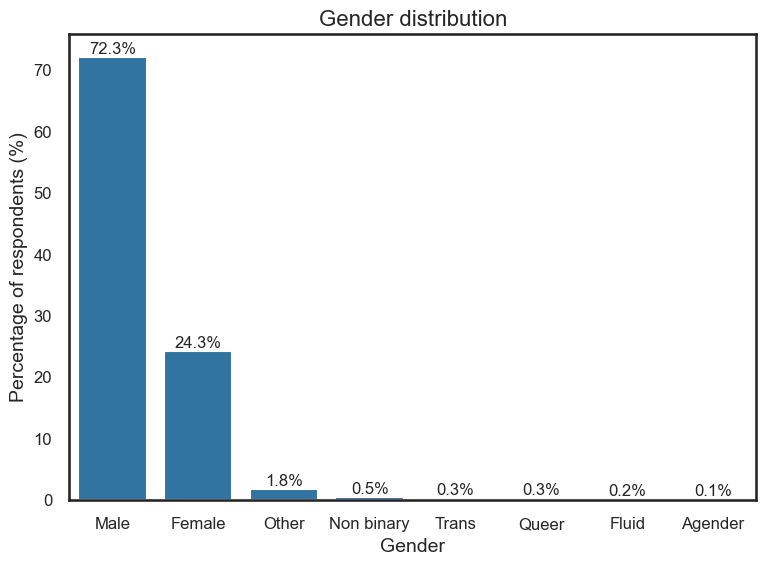

In [25]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=gender, x="Gender", y="Percentage", color=ACCENT_COLOR)
ax.set(
    title="Gender distribution",
    ylabel="Percentage of respondents (%)",
    xlabel="Gender",
)

ax.tick_params(axis="both", labelsize=12)
ax.set_title(ax.get_title(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=12)

plt.tight_layout()

Over 95% of the participants are either female or male, and 72% of all survey participants are male. 

## Race for USA

Now, looking at race of participants (this question is answered for those working in the USA only): 

In [26]:
question_missing_stats(89, total_participants)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,89,1525,537,35.213115,12.731152


Percentage of USA workers who answered this question: 

In [27]:
(1523/total_participants_USA)*100

81.3568376068376

This is enough data to continue looking at race in the USA according to survey year: 

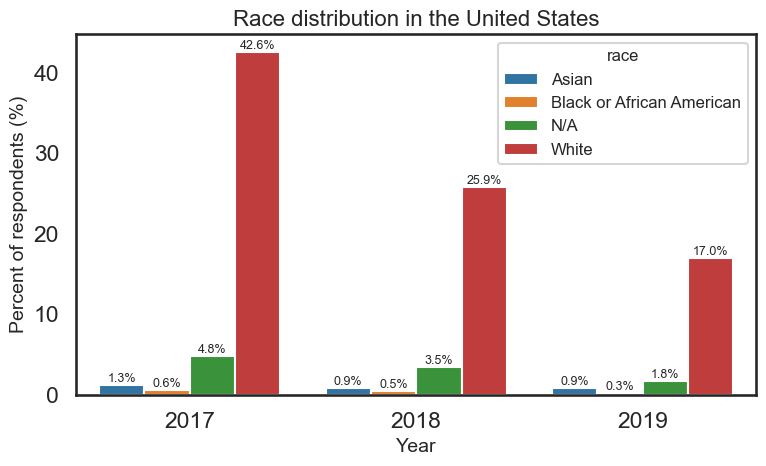

In [28]:
q = """ 
WITH t1 AS (SELECT UserID, SurveyID, CASE WHEN AnswerText LIKE 'White' THEN 'White'
WHEN AnswerText LIKE 'Caucasian' THEN 'White' 
WHEN AnswerText LIKE 'Asian' THEN 'Asian' 
WHEN AnswerText LIKE 'Black or African American' THEN 'Black or African American'
Else 'N/A' END AS race
FROM Answer
WHERE QuestionID = 89), 

t2 AS (SELECT AnswerText work_country, UserID
FROM Answer
WHERE QuestionID = 50)

SELECT t1.SurveyID year, t1.race, COUNT(t1.race) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
WHERE t2.work_country LIKE 'United States of America'
GROUP BY 1, 2
"""
race = pd.read_sql(q, connection)
total_answers_us = race["frequency"].sum()
race["percent"] = race["frequency"] / total_answers_us * 100
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=race, x="year", y="percent", hue="race")
ax.set(
    title="Race distribution in the United States",
    ylabel="Percent of respondents (%)",
    xlabel="Year",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()

Race data only given for survey years 2017-2019 for the USA. Most people who answered this question identify as being 'White', though about half of the people who work in the USA have answered this question. 


## Work conditions

Now, examining work conditions for survey participants in the top 3 countries, starting with the number of employees in participant's organization: 

In [29]:
question_missing_stats(8, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,8,2294,335,14.603313,14.603313


Having 85% of data for this question is enough to continue: 

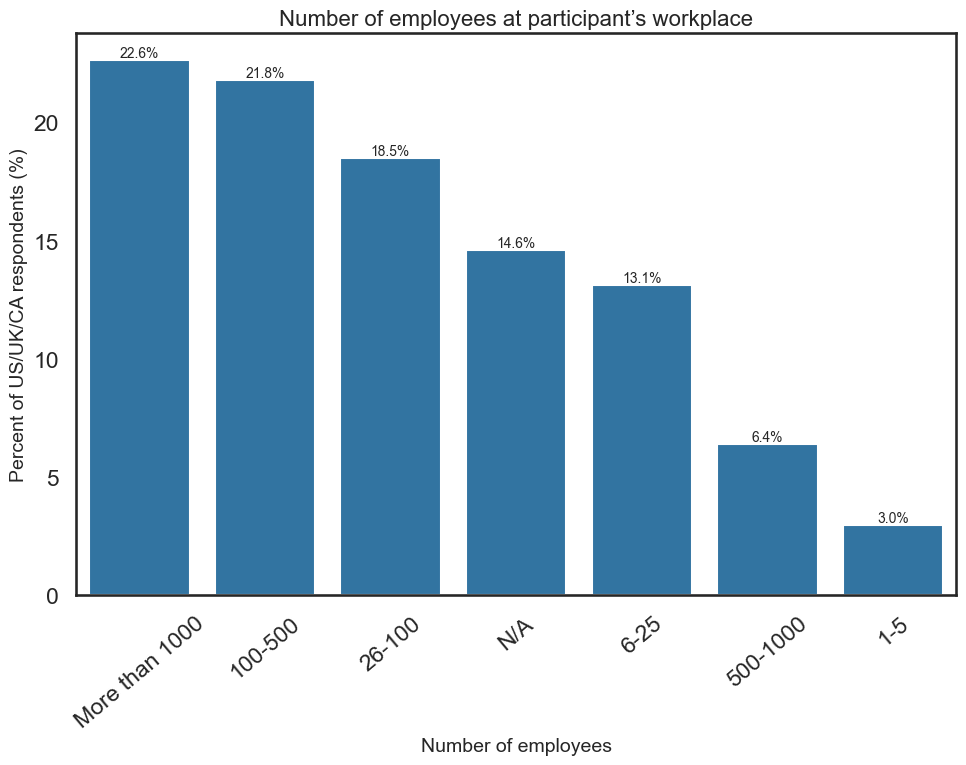

In [30]:
q = """
WITH country AS (
    SELECT UserID, AnswerText AS work_country
    FROM Answer
    WHERE QuestionID = 50
),
employees AS (
    SELECT UserID,
           CASE WHEN AnswerText = -1 THEN 'N/A'
                ELSE AnswerText
           END AS no_employees
    FROM Answer
    WHERE QuestionID = 8
)
SELECT
    e.no_employees,
    COUNT(*) AS frequency
FROM employees e
JOIN country c USING (UserID)
WHERE c.work_country IN (
    'United States of America', 'United Kingdom', 'Canada'
)
GROUP BY e.no_employees
ORDER BY frequency DESC;
"""
no_employees = pd.read_sql(q, connection)

total_q8_top3 = no_employees["frequency"].sum()
no_employees["percent"] = no_employees["frequency"] / total_q8_top3 * 100

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=no_employees, x="no_employees", y="percent", color=ACCENT_COLOR)
plt.xticks(rotation=40)
ax.set(
    title="Number of employees at participant’s workplace",
    ylabel="Percent of US/UK/CA respondents (%)",
    xlabel="Number of employees",
)
ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=10)
plt.tight_layout()


Survey participants work in companies with variable amounts of staff.

Now, what kind of positions do survey participants occupy (question data only available from 2016)? 

Ensuring there aren't too many missing values: 

In [31]:
question_missing_stats(117, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,117,2055,0,0.0,0.0


Examining company position grouped by gender, as only 10% of respondants didn't answer this question:  

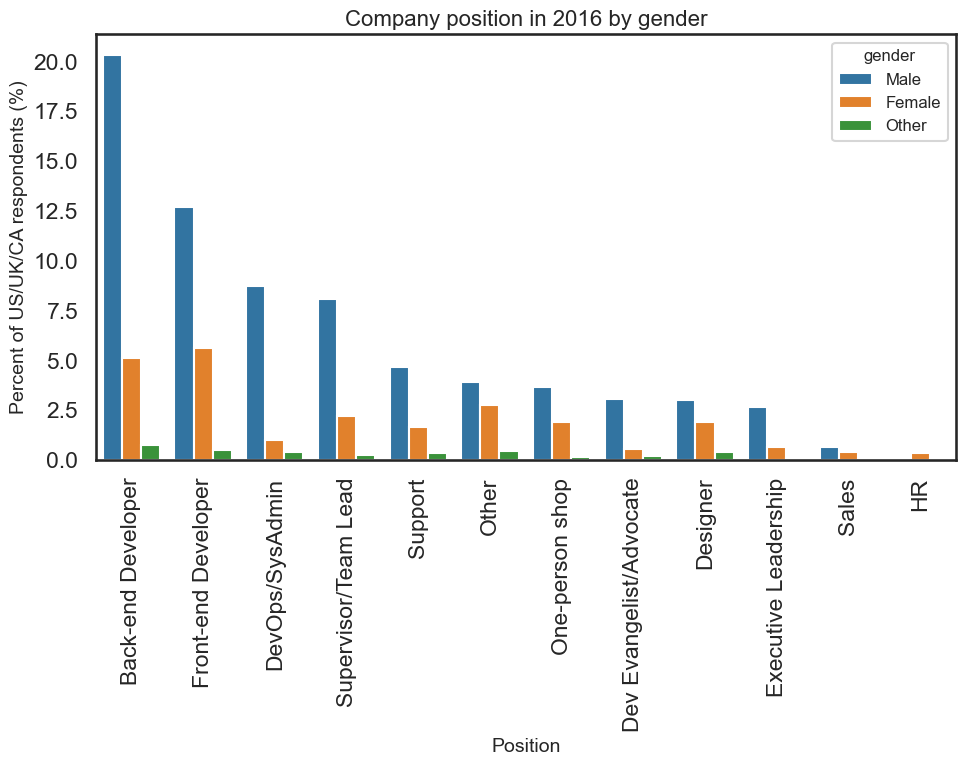

In [32]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
         WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
         WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
         WHEN AnswerText LIKE 'female' THEN 'Female' 
         WHEN AnswerText LIKE 'MALE' THEN 'Male'
         WHEN AnswerText LIKE '%Male%' THEN 'Male' 
         WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
         WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
         WHEN AnswerText LIKE 'male' THEN 'Male'  
         ELSE 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText
    FROM Answer
    WHERE QuestionID = 117)

SELECT t1.gender, t3.AnswerText AS Position, COUNT(t1.gender) AS frequency
FROM t1
JOIN t2 ON t1.UserID = t2.UserID
JOIN t3 ON t2.UserID = t3.UserID
WHERE t2.work_country IN (
    'United States of America', 'United Kingdom', 'Canada'
)
GROUP BY t1.gender, t3.AnswerText
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

total_q117 = c["frequency"].sum()
c["percent"] = c["frequency"] / total_q117 * 100

plt.figure(figsize=(10, 8))
n_levels = c["gender"].nunique()
palette = PALETTE[:n_levels]

ax = sns.barplot(data=c, x="Position", y="percent", hue="gender", palette=palette)
plt.xticks(rotation=90)
ax.set(
    title="Company position in 2016 by gender",
    ylabel="Percent of US/UK/CA respondents (%)",
    xlabel="Position",
)
plt.tight_layout()


For the USA, the UK, and Canada, the most popular position is a developer. Women are more present than men only in the HR sector in 2016.

Do most survey participants have a tech role? 

In [33]:
question_missing_stats(13, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,13,2294,1031,44.94333,44.94333


Almost half of answers for this question are missing. Looking at this through survey years: 

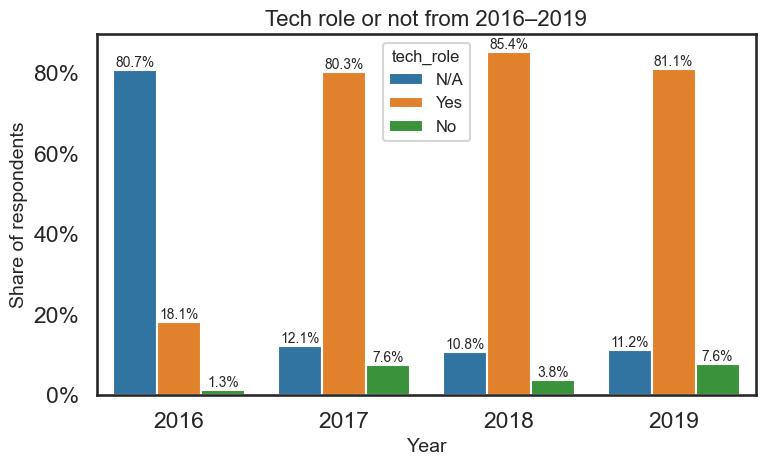

In [34]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = 1 THEN 'Yes' 
    WHEN AnswerText = 0 THEN 'No' 
    Else 'N/A' END AS tech_role
    FROM Answer
    WHERE QuestionID = 13)

SELECT t1.SurveyID year, t3.tech_role, COUNT(t1.SurveyID) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection).copy()
c["share"] = c["frequency"] / c.groupby("year")["frequency"].transform("sum")

plt.figure(figsize=(8, 5))
n_levels = c["tech_role"].nunique()  
palette = PALETTE[:n_levels]

ax = sns.barplot(
    data=c,
    x="year",
    y="share",
    hue="tech_role",
    palette=palette,
)
ax.set(
    title="Tech role or not from 2016–2019",
    ylabel="Share of respondents",
    xlabel="Year",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))

for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=10)

plt.tight_layout()

From 2017-2019, it is more likely for survey participants to have tech roles than not. This question was largely not applicable in 2016.

General population of survey takers: 
- From the USA
- Aged between 29 and 55 years old
- Either identify as a male or female
- Work in the tech field. 


For the rest of the project, survey respondents working in the top three countries (USA, UK, and Canada) are analyzed to keep insights easy to generalize.
Sampling bias: 
- There could be a race, country, or age sampling bias in this survey, due to the fact that surveys are given in a workplace (mostly pertaining to the tech industry), which could bias the sampling probability. For example, the fact that the survey sample consists mostly of white males or females from the USA could indicate that most surveys were given in the USA and not other countries. 



# Mental health in the workplace examination

Mental health related questions are now examined.

## Employer provided mental health insurance

Next, looking at the question: 'Does your employer provide mental health benefits as part of healthcare coverage?': 

In [35]:
q = """
WITH country AS (
    SELECT UserID, AnswerText AS work_country
    FROM Answer
    WHERE QuestionID = 50
),
benefits AS (
    SELECT
        UserID,
        CASE
            WHEN AnswerText = -1 THEN 'N/A'
            WHEN AnswerText LIKE 'Not eligible for coverage / NA' THEN 'N/A'
            WHEN AnswerText LIKE '%know' THEN 'N/A'
            ELSE AnswerText
        END AS employer_mental_health_benefits
    FROM Answer
    WHERE QuestionID = 10
)
SELECT
    b.employer_mental_health_benefits,
    COUNT(*) AS frequency
FROM benefits b
JOIN country c USING (UserID)
WHERE c.work_country IN (
    'United States of America', 'United States',
    'United Kingdom',
    'Canada'
)
GROUP BY b.employer_mental_health_benefits
ORDER BY frequency DESC;
"""
employer_insurance = pd.read_sql(q, connection)
total_q10_top3 = employer_insurance["frequency"].sum()
employer_insurance["Percent"] = (
    employer_insurance["frequency"] / total_q10_top3 * 100
)
employer_insurance


,employer_mental_health_benefits,frequency,Percent
0,Yes,1163,50.697472
1,N/A,939,40.932868
2,No,192,8.369660


Out of the total sample, about 50% of survey participants have mental health benefits as part of their insurance plan from work, and about 40% of survey participants do not have an answer for this this question.  

Do most of these employees know about the mental health benefits as part of their company insurance?

In [36]:
question_missing_stats(14, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,14,2294,478,20.836966,20.836966


About 21% of answers to this question are missing. Looking at awareness of mental health benefits grouped by gender for the top 3 countries: 

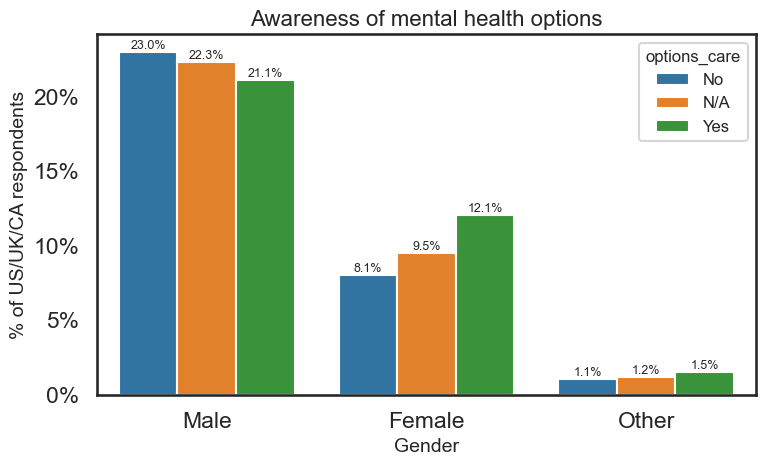

In [37]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    WHEN AnswerText LIKE 'I am not sure' THEN 'N/A'
    ELSE AnswerText END AS options_care
    FROM Answer
    WHERE QuestionID = 14)

SELECT t1.gender gender, t3.options_care, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)
total_q14_top3 = c["frequency"].sum()
c["share"] = c["frequency"] / total_q14_top3
n_levels = c["options_care"].nunique()
palette = PALETTE[:n_levels]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=c,
    x="gender",
    y="share",
    hue="options_care",
    palette=palette,
)

ax.set(
    title="Awareness of mental health options",
    ylabel="% of US/UK/CA respondents",
    xlabel="Gender",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9)

plt.tight_layout()

In total, more survey participants don't know or had a non applicable answer about their insurance options for mental health care. In general, female and other genders are more aware of the mental health options under their work insurance than males. 

## Mental health family history

Next, examining the survey question: Do survey participants working in the USA, UK, or Canada have a family history of mental health issues? 

Ensuring that not too many missing values are present for this question: 

In [38]:
question_missing_stats(6, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,6,2294,0,0.0,0.0


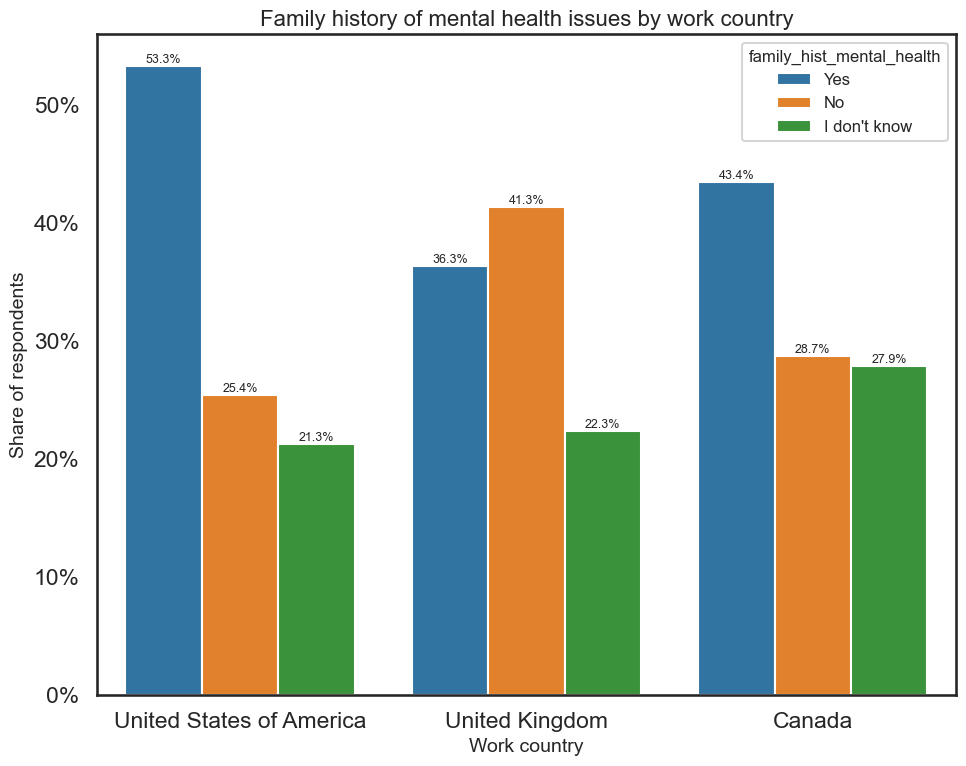

In [39]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText
    FROM Answer
    WHERE QuestionID = 6)

SELECT t2.work_country, t3.AnswerText family_hist_mental_health, COUNT(t2.work_country) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)
c["share"] = c["frequency"] / c.groupby("work_country")["frequency"].transform("sum")

ax = sns.barplot(
    data=c,
    x="work_country",
    y="share",
    hue="family_hist_mental_health",
)
ax.set(
    title="Family history of mental health issues by work country",
    xlabel="Work country",
    ylabel="Share of respondents",
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9)

plt.tight_layout()

In the USA and Canada, more people have a family history of mental health than not, while most people who answered this question in the UK do not. 

## Treatment for mental health conditions

Now, looking at the question 'Have you ever sought treatment for a mental health disorder from a mental health professional?':

In [40]:
question_missing_stats(7, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,7,2294,0,0.0,0.0


No missing values are present. 

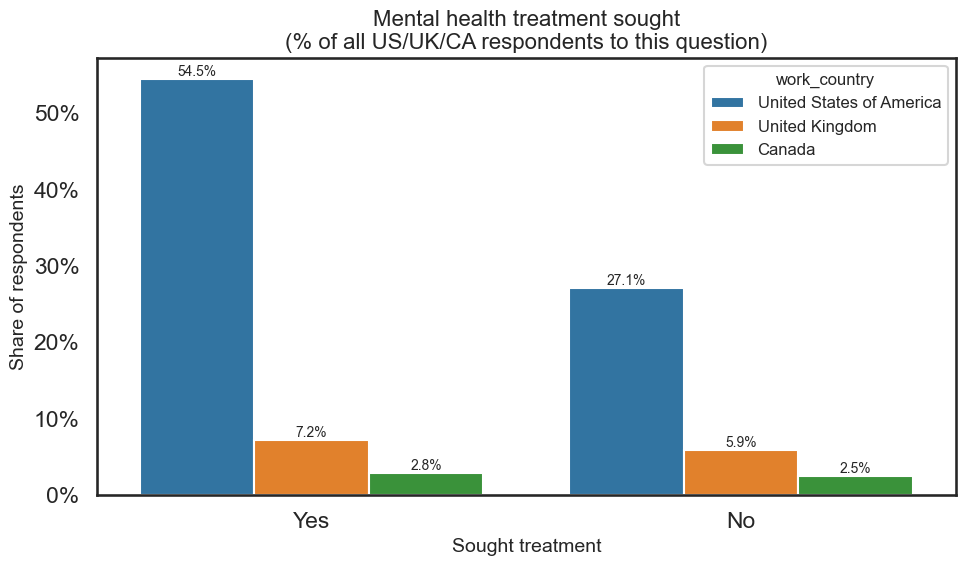

In [41]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = 1 THEN 'Yes' ELSE 'No' END AS sought_treatment
    FROM Answer
    WHERE QuestionID = 7)

SELECT t2.work_country, t3.sought_treatment, COUNT(t2.work_country) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection).copy()
total_q7_top3 = c["frequency"].sum()
c["share_total"] = c["frequency"] / total_q7_top3

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=c,
    x="sought_treatment",
    y="share_total",
    hue="work_country",
)

ax.set(
    title="Mental health treatment sought\n(% of all US/UK/CA respondents to this question)",
    xlabel="Sought treatment",
    ylabel="Share of respondents",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=10)

plt.tight_layout()

Many more people in the USA have sought treatment for mental health issues than not. This difference is much smaller in the UK and Canada, though the trend is still present.

## Past and current mental health disorders: 

Examining missing values for participants with past mental health disorders working in the USA, CA, UK: 

In [42]:
question_missing_stats(32, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,32,2294,12,0.523104,0.523104


Most poeple have answered this question. Grouped by gender: 

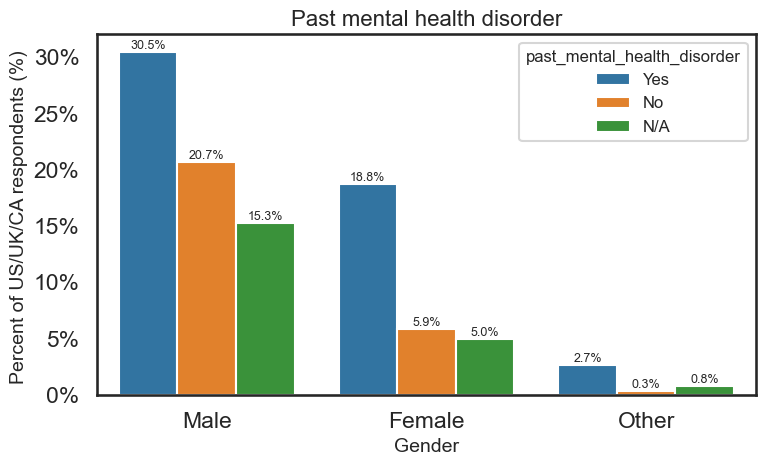

In [43]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Possibly' THEN 'N/A'
    WHEN AnswerText = -1 THEN 'N/A' 
    WHEN AnswerText LIKE '%know' THEN 'N/A'
    WHEN AnswerText LIKE 'Maybe' THEN 'N/A'
    ELSE AnswerText END AS past_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 32)

SELECT t1.gender gender, t3.past_mental_health_disorder, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)
total_q32_top3 = c["frequency"].sum()
c["share_total"] = c["frequency"] / total_q32_top3

n_levels = c["past_mental_health_disorder"].nunique()
palette = PALETTE[:n_levels]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=c,
    x="gender",
    y="share_total",
    hue="past_mental_health_disorder",
    palette=palette,
)

ax.set(
    title="Past mental health disorder",
    xlabel="Gender",
    ylabel="Percent of US/UK/CA respondents (%) ",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))

for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9)

plt.tight_layout()

Compared to males, females and other genders have higher proportions of past mental health disorders.

Looking at current mental health disorders grouped by country and then by gender: 

In [44]:
question_missing_stats(33, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,33,2294,0,0.0,0.0


No missing values are present.

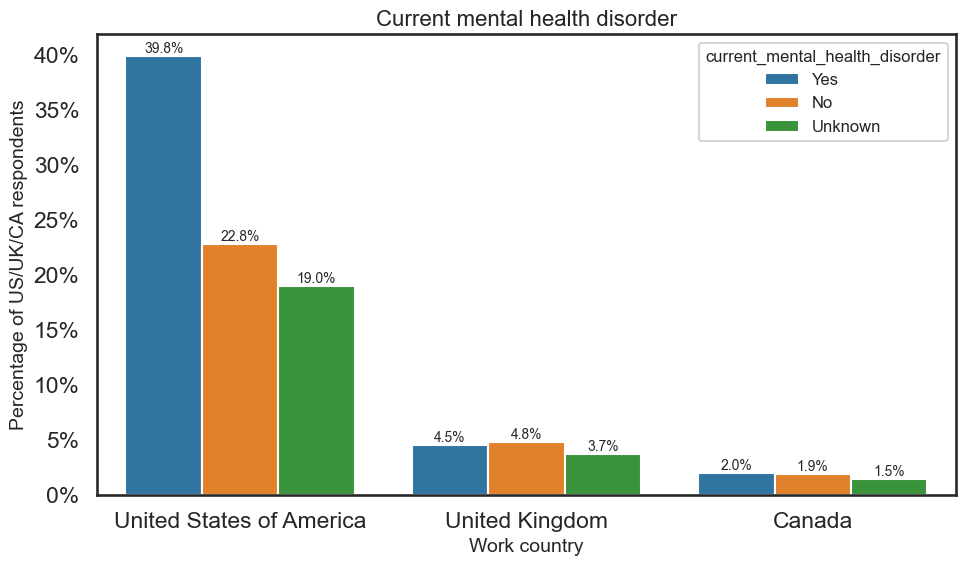

In [45]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
    WHEN AnswerText LIKE 'No' THEN 'No' 
    ELSE 'Unknown' END AS current_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 33)

SELECT t2.work_country, t3.current_mental_health_disorder, COUNT(t2.work_country) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection).copy()
total_q33_top3 = c["frequency"].sum()
c["share_total"] = c["frequency"] / total_q33_top3

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=c,
    x="work_country",
    y="share_total",
    hue="current_mental_health_disorder",
)

ax.set(
    title="Current mental health disorder",
    xlabel="Work country",
    ylabel="Percentage of US/UK/CA respondents",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=10)

plt.tight_layout()


There is a higher proportion of mental health disorders in the USA than in the UK or in Canada. It is important to note that most survey participants are from the USA. 

Now, looking at current mental health disorders in the USA, UK, and Canada grouped by gender:

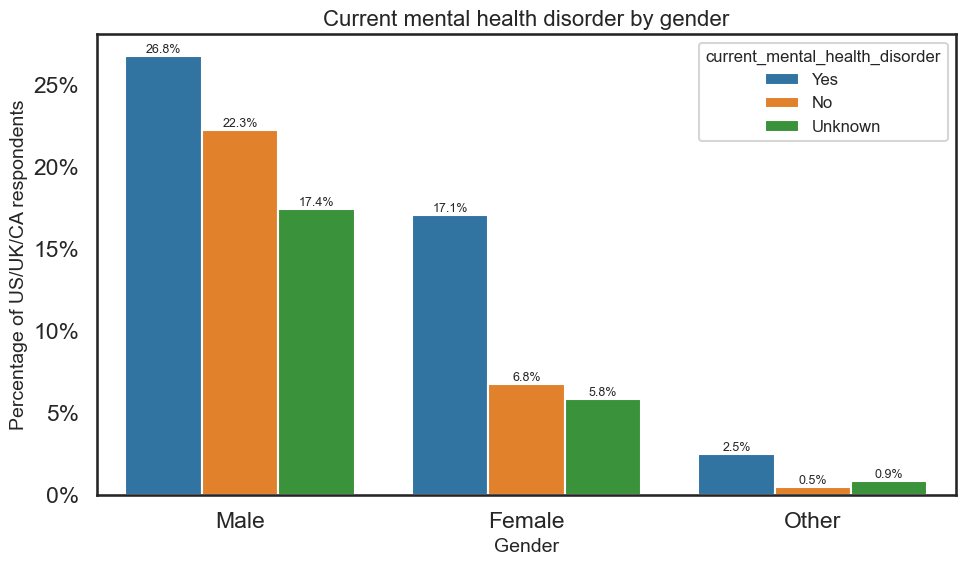

In [46]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
    WHEN AnswerText LIKE 'No' THEN 'No' 
    ELSE 'Unknown' END AS current_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 33)

SELECT t1.gender gender, t3.current_mental_health_disorder, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)
total_q33_top3 = c["frequency"].sum()
c["share_total"] = c["frequency"] / total_q33_top3
n_levels = c["current_mental_health_disorder"].nunique()
palette = PALETTE[:n_levels]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=c,
    x="gender",
    y="share_total",
    hue="current_mental_health_disorder",
    palette=palette,
)

ax.set(
    title="Current mental health disorder by gender",
    xlabel="Gender",
    ylabel="Percentage of US/UK/CA respondents",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9)

plt.tight_layout()

It seems there is a higher proportion of females and other genders that have current mental health disorders as compared to males in the USA, UK, and Canada. 

## Diagnosed mental health disorders

Looking at survey participants who have been diagnosed with mental illnesses, starting with missing values: 

In [47]:
question_missing_stats(34, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,34,2294,607,26.460331,26.460331


About a quarter of the respondents from US, Canada, and the UK did not answer this question. Examining diagnoses through the survey timespan: 

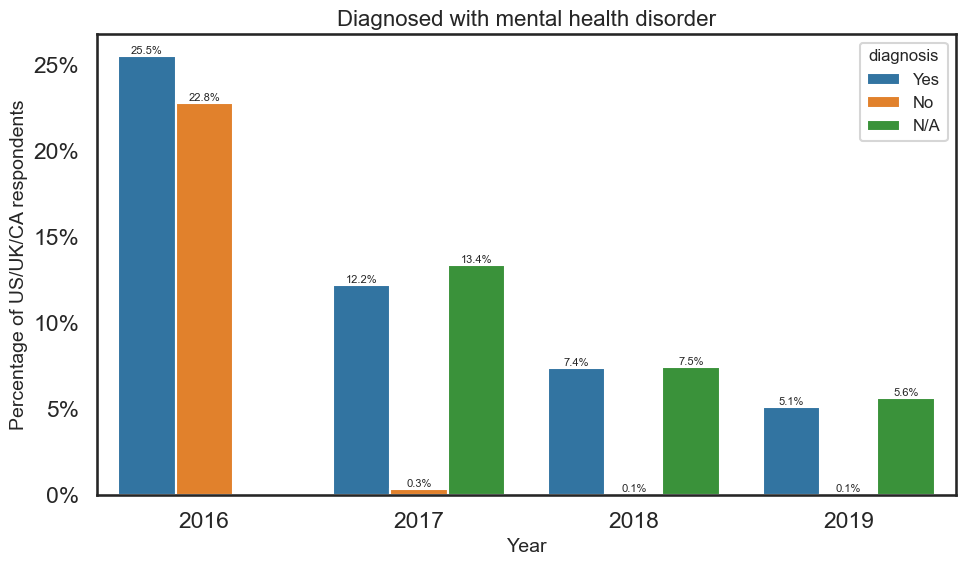

In [48]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    ELSE AnswerText END AS diagnosis
    FROM Answer
    WHERE QuestionID = 34)

SELECT t1.SurveyID year, t3.diagnosis, COUNT(t1.SurveyID) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)
total_q34_top3 = c["frequency"].sum()
c["share_total"] = c["frequency"] / total_q34_top3
n_levels = c["diagnosis"].nunique()
palette = PALETTE[:n_levels]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=c,
    x="year",
    y="share_total",
    hue="diagnosis",
    palette=palette,
)

ax.set(
    title="Diagnosed with mental health disorder",
    xlabel="Year",
    ylabel="Percentage of US/UK/CA respondents",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=8)

plt.tight_layout()

In each year in the USA, UK, and Canada, similar amounts of survey respondants have been diagnosed with a mental health disorder, of this question is not applicable. 

## Diagnosed Condition Prevalence Rates

Examining missing values for diagnosed conditions: 

In [49]:
question[question['questionid'] == 115]

,questiontext,questionid
101,"If yes, what condition(s) have you been diagnosed with?",115


In [50]:
question_missing_stats(115, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,115,1648,631,38.288835,27.506539


38% of answers are missing for this question. At least half of survey respondents do not have a mental health disorder, so it follows that quite a few people do not have an answer to this question.

In [51]:
q = """ 
WITH t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    ELSE AnswerText END AS diagnosed_condition
    FROM Answer
    WHERE QuestionID = 115)

SELECT t3.diagnosed_condition, COUNT(t3.diagnosed_condition) frequency
FROM t2
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1
ORDER BY frequency DESC
LIMIT 6
"""

diagnosed_condition_top3_countries = pd.read_sql(q, connection)
diagnosed_condition_top3_countries = diagnosed_condition_top3_countries.drop(diagnosed_condition_top3_countries[(diagnosed_condition_top3_countries.diagnosed_condition == 'N/A')].index)
diagnosed_condition_top3_countries = diagnosed_condition_top3_countries.assign(Percent_participants_top3_countries = lambda x: x.frequency / total_participants_USA_UK_Canada * 100)
diagnosed_condition_top3_countries = diagnosed_condition_top3_countries.assign(
    p_hat=lambda x: (1.0 * x.frequency) / (1.0 * total_participants_USA_UK_Canada)
)
diagnosed_condition_top3_countries

,diagnosed_condition,frequency,Percent_participants_top3_countries,p_hat
1,"Mood Disorder (Depression, Bipolar Disorder, etc)",351,15.300785,0.153008
2,"Anxiety Disorder (Generalized, Social, Phobia, etc)",296,12.903226,0.129032
3,Attention Deficit Hyperactivity Disorder,111,4.838710,0.048387
4,Post-traumatic Stress Disorder,62,2.702703,0.027027
5,Obsessive-Compulsive Disorder,38,1.656495,0.016565


Mood and anxiety disorders are the top 2 diagnosed disorders in this sample. Note: Including the ratio of the number of diagnosed individuals who work in the USA, UK, or Canada as p_hat. Now, including the margin of error (ME) for participants in the top 3 countries: 

In [52]:
diagnosed_condition_top3_countries["ME"] = diagnosed_condition_top3_countries["frequency"].apply(ME)
diagnosed_condition_top3_countries

,diagnosed_condition,frequency,Percent_participants_top3_countries,p_hat,ME
1,"Mood Disorder (Depression, Bipolar Disorder, etc)",351,15.300785,0.153008,0.014732
2,"Anxiety Disorder (Generalized, Social, Phobia, etc)",296,12.903226,0.129032,0.013719
3,Attention Deficit Hyperactivity Disorder,111,4.838710,0.048387,0.008781
4,Post-traumatic Stress Disorder,62,2.702703,0.027027,0.006636
5,Obsessive-Compulsive Disorder,38,1.656495,0.016565,0.005223


Plotting the top 5 diagnosed disorders in the top 3 countries:

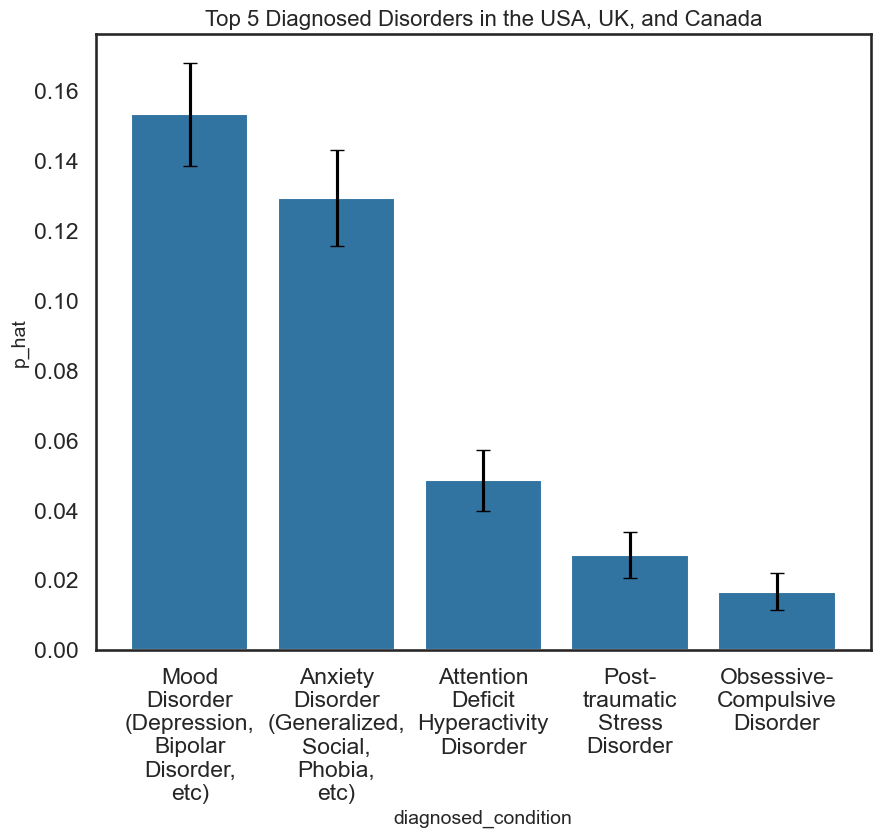

In [53]:
ax = sns.barplot(x="diagnosed_condition", y="p_hat", data=diagnosed_condition_top3_countries)
plt.errorbar(
    diagnosed_condition_top3_countries.diagnosed_condition, diagnosed_condition_top3_countries.p_hat, yerr=diagnosed_condition_top3_countries.ME, fmt="none", c="black", capsize=5
)
plt.title("Top 5 Diagnosed Disorders in the USA, UK, and Canada")
wrap_labels(ax, 10)
plt.show()

These error bars show the margin of error with a 95% confidence level, which meants that the true proportion of people with mental health disorders for this sample lies in between this interval. 

However, there are some key assumptions missing: 
- Not necessarily a random sample
- The entries are not necessarily independent from each other

## Mental Health Involvement with Work Output

Looking at people who identify as having a mental health disorder and the effect on their work. The exact question is : 

'If you have a mental health disorder, how often do you feel that it interferes with your work when being treated effectively?' This is also compared with the opposite question: 'If you have a mental health disorder, how often do you feel that it interferes with your work when not being treated effectively (i.e., when you are experiencing symptoms)?'

In [54]:
question_missing_stats(48, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,48,2294,0,0.0,0.0


In [66]:
question_missing_stats(49, total=total_participants_USA_UK_Canada, country_filter=True)

,question_id,n_answers,n_missing,pct_missing_of_answers,pct_missing_of_total
0,49,2294,0,0.0,0.0


No missing values are present for these questions.

In [67]:
q_eff = """
WITH country AS (
    SELECT UserID, AnswerText AS work_country
    FROM Answer
    WHERE QuestionID = 50
),
eff AS (
    SELECT
        UserID,
        CASE
            WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A'
            ELSE AnswerText
        END AS interference
    FROM Answer
    WHERE QuestionID = 48
)
SELECT
    eff.interference,
    COUNT(*) AS frequency
FROM eff
JOIN country USING (UserID)
WHERE work_country IN (
    'United States of America',
    'United Kingdom',
    'Canada'
)
GROUP BY eff.interference
ORDER BY frequency DESC;
"""
c_eff = pd.read_sql(q_eff, connection)
c_eff["treatment"] = "Effective"

q_ineff = """
WITH country AS (
    SELECT UserID, AnswerText AS work_country
    FROM Answer
    WHERE QuestionID = 50
),
ineff AS (
    SELECT
        UserID,
        CASE
            WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A'
            ELSE AnswerText
        END AS interference
    FROM Answer
    WHERE QuestionID = 49
)
SELECT
    ineff.interference,
    COUNT(*) AS frequency
FROM ineff
JOIN country USING (UserID)
WHERE work_country IN (
    'United States of America',
    'United Kingdom',
    'Canada'
)
GROUP BY ineff.interference
ORDER BY frequency DESC;
"""
c_ineff = pd.read_sql(q_ineff, connection)
c_ineff["treatment"] = "Ineffective"

df = pd.concat([c_eff, c_ineff], ignore_index=True)
df["share_within_treatment"] = (
    df["frequency"] /
    df.groupby("treatment")["frequency"].transform("sum")
)

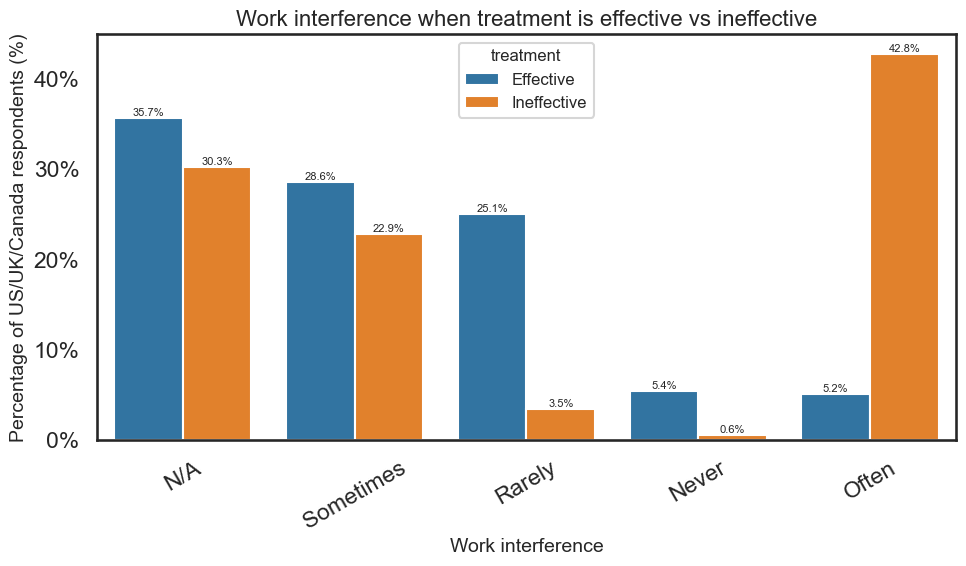

In [70]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x="interference",
    y="share_within_treatment",
    hue="treatment",
    palette=PALETTE[: df["treatment"].nunique()],
)
ax.set(
    title="Work interference when treatment is effective vs ineffective",
    xlabel="Work interference",
    ylabel="Percentage of US/UK/Canada respondents (%)",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.xticks(rotation=30)

for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=8)

plt.tight_layout()


In the USA, UK, and Canada, people with mental health conditions and effective treatment do not find their work frequently affected by their condition. Only 5% of those with effective treatment find that their mental health condition interferes often with their work. 43% of survey respondants with mental health conditions often find their work is often affected when their condition does not have an effective treatment.

Finally, examining the link between survey respondents with past or current mental health conditions with or without a family history of mental health disorders and the amount of time they find their work to be affected by potential mental health disorders: 

In [72]:
q = """
WITH country AS (
    SELECT
        UserID,
        AnswerText AS work_country
    FROM Answer
    WHERE QuestionID = 50
),

family_hist AS (
    -- Q6: family history of mental health issues
    SELECT
        UserID,
        AnswerText AS family_hist
    FROM Answer
    WHERE QuestionID = 6
),

past_disorder AS (
    -- Q32: past mental health disorder
    SELECT
        UserID,
        AnswerText AS past_disorder
    FROM Answer
    WHERE QuestionID = 32
),

history_flag AS (
    -- Collapse family + past into a single history yes/no flag
    SELECT
        c.UserID,
        CASE
            WHEN fh.family_hist = 'Yes'
                 OR pd.past_disorder IN ('Yes', 'Possibly')
            THEN 'History yes'
            ELSE 'History no'
        END AS history
    FROM country c
    LEFT JOIN family_hist fh USING (UserID)
    LEFT JOIN past_disorder pd USING (UserID)
),

current_disorder AS (
    -- Q33: current mental health disorder
    SELECT
        UserID,
        CASE
            WHEN AnswerText LIKE 'Yes' THEN 'Yes'
            WHEN AnswerText LIKE 'No' THEN 'No'
            ELSE 'Unknown'
        END AS current_disorder
    FROM Answer
    WHERE QuestionID = 33
),

productivity AS (
    -- Q55: percent of work time affected
    SELECT
        UserID,
        CASE
            WHEN AnswerText = -1 THEN 'N/A'
            ELSE AnswerText
        END AS percent_work_affected
    FROM Answer
    WHERE QuestionID = 55
)

SELECT
    c.work_country,
    h.history,
    cd.current_disorder,
    p.percent_work_affected
FROM country c
JOIN history_flag h     USING (UserID)
JOIN current_disorder cd USING (UserID)
JOIN productivity p      USING (UserID)
WHERE c.work_country IN ('United States of America', 'United States', 'United Kingdom', 'Canada');


"""

df = pd.read_sql(q, connection)


In [73]:
df

,work_country,history,current_disorder,percent_work_affected
0,United Kingdom,History yes,No,N/A
1,United States of America,History yes,Yes,N/A
2,United Kingdom,History no,No,N/A
3,United Kingdom,History yes,Yes,1-25%
4,United States of America,History yes,Yes,N/A
...,...,...,...,...
2289,United States of America,History yes,Yes,N/A
2290,United States of America,History yes,Yes,N/A
2291,United States of America,History no,No,N/A
2292,United States of America,History no,No,26-50%


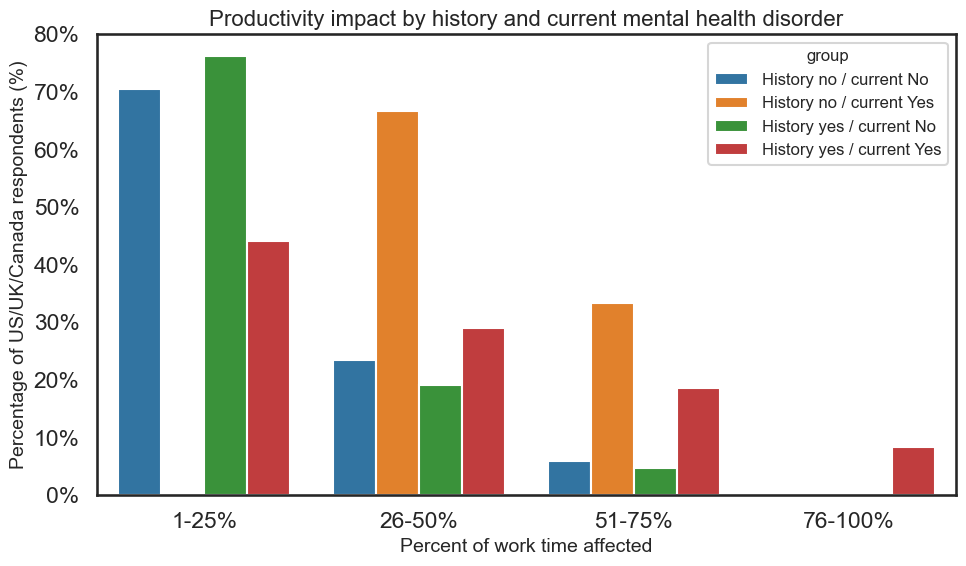

In [77]:
df = df.copy()
df = df[df["percent_work_affected"] != "N/A"]
df = df[df["current_disorder"].isin(["Yes", "No"])]
df = df[df["work_country"].isin(['United States of America', 'United Kingdom', 'Canada'])]
df["group"] = df["history"] + " / current " + df["current_disorder"]
summary = (
    df.groupby(["group", "percent_work_affected"])
      .size()
      .rename("n")
      .reset_index()
)
summary["share"] = summary["n"] / summary.groupby("group")["n"].transform("sum")
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary,
    x="percent_work_affected",
    y="share",
    hue="group",
)

ax.set(
    title="Productivity impact by history and current mental health disorder",
    xlabel="Percent of work time affected",
    ylabel="Percentage of US/UK/Canada respondents (%)",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()



This plot shows that survey respondents working in the USA, UK, or Canada with no current mental health disorders generally do not have their work affected by a mental health disorder. On the contrary, those who do have mental health disorders find that often over a quarter of their work time is affected. This is an indication that mental health conditions should be treated properly to increase workplace producvitity.

# Conclusions: 

In conclusion, this notebook's objective was to answer the following questions: 
1. Who participated in the survey? 

From examining survey questions, it was found that the general population under examination are white men working in the USA aged between 25-45 who work in the tech field with companies of varying sizes. In general, employers provide mental health benefits, though about half of survey participants are not aware of these exact options. Most data was sampled during 2016-2019. 

2. Which mental health conditions are most prevalent for this population? 

The most prevalent diagnosed mental health conditions for participants in the USA, UK, and Canada are mood, anxiety, and attention deficit hyperactivity disorders, where mood disorders such as depression or bipolar disorder affect between 14-16% of the sample. 

3. How does treatment for mental health conditions affect productivity at work?

- In the USA, UK, and Canada: 
    - About half of survey participants have a family history of mental health issues.
    - Most of these people have sought help for mental health issues at some point (USA). This number changes to about half in the UK and in Canada. 
    - Most people have dealt with a past mental health disorder (females and other genders with higher proportions than males). 
    - A higher proportion of people in the United States say they have a current mental health disorder compared to the UK and to Canada. This proportion is also higher non-males. 
    - Throughout 2016-2019, about half of respondents of these nationalities have been diagnosed with a mental health disorder. 
    - Work productivity is generally unaltered or minimally altered for those with treated conditions. 
    - With ineffective treatment, most people struggling with mental health issues find that it interferes with their work. 
    - Participants with untreated mental health conditions have found their work productivity to be dimished, and affects between 75-100% of their work time for about 10% of diagnosed participants.


Improvements to be made: 
- Sampling bias and randomness: It is impossible to say that this data is a random selection of people or that survey entries have no influence on each other.
- Examining more recent data, with an equal sample size in terms of gender and country. 
- Evaluating to what extent exactly that mental health issues affect workplace productivity. This has not been evaluated conclusively here.
- Monitoring mental health treatment quality and its effect on both workplace productivity and on general respondent wellbeing would be an interesting next step.  
